# Summary
This notebook trains a very small character-level language model on the Tiny Shakespeare dataset and then uses it to generate text.

## Install dependencies
Install the Python packages used in the notebook: PyTorch for the model and NumPy/Matplotlib for numerical work and plotting.

In [1]:
# uncomment if the following packages are not installed
# pip install torch matplotlib numpy

## Load the text corpus
Download the Tiny Shakespeare dataset and prints basic size statistics so we know what data the model will learn from.

In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "tinyshakespeare.txt"

urllib.request.urlretrieve(url, filename)

with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text):,}")
print(f"Number of words in dataset: {len(text.split()):,}\n")

print(f"First 200 characters:\n{text[:200]}")

Length of dataset in characters: 1,115,394
Number of words in dataset: 202,651

First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Build the character vocabulary
Find every unique character in the corpus and create two lookup tables: one for encoding characters as integers and one for decoding integers back to text.

In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join([itos[i] for i in ids])

print(f"Vocabulary size: {vocab_size}")

words = text.split()

print(f"Number of words/tokens: {len(words)}")

Vocabulary size: 65
Number of words/tokens: 202651


## Create training examples
Turn words into supervised examples where a fixed-length context predicts the next character, then splits those examples into train, validation, and test sets.

In [4]:
import torch
import random


# build the dataset
block_size = 5  # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:])     # 10%

print(f"shape(Xtr): {tuple(Xtr.shape)}")
print(f"shape(Ytr): {tuple(Ytr.shape)}")

shape(Xtr): (886635, 5)
shape(Ytr): (886635,)


## Define the neural network
Next, we define a small feed-forward character model. It maps the current context to logits over the vocabulary and computes cross-entropy loss for next-character prediction.

In [5]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, vocab_size, block_size, layer_sizes):
        super().__init__()
        self.block_size = block_size
        self.vocab_size = vocab_size

        hidden_size = layer_sizes[0]
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(block_size, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, vocab_size),
        )

    def forward(self, x):
        # x is of shape (batch_size, block_size)
        x = x.float()  # convert indices to floats for the linear layers
        return self.layers(x)

    def loss(self, x, y):
        logits = self.forward(x)
        loss = torch.nn.functional.cross_entropy(logits, y)
        return loss


## Train and evaluate the model
Instantiate the network, train it with Adam, record the training loss, plot the loss curve, and report validation loss on the development split.

Number of parameters: 14265
Network architecture:
NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=5, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=65, bias=True)
  )
)
epoch  1 | loss 2.7815
epoch  2 | loss 2.7420
epoch  3 | loss 2.7134
epoch  4 | loss 2.6957


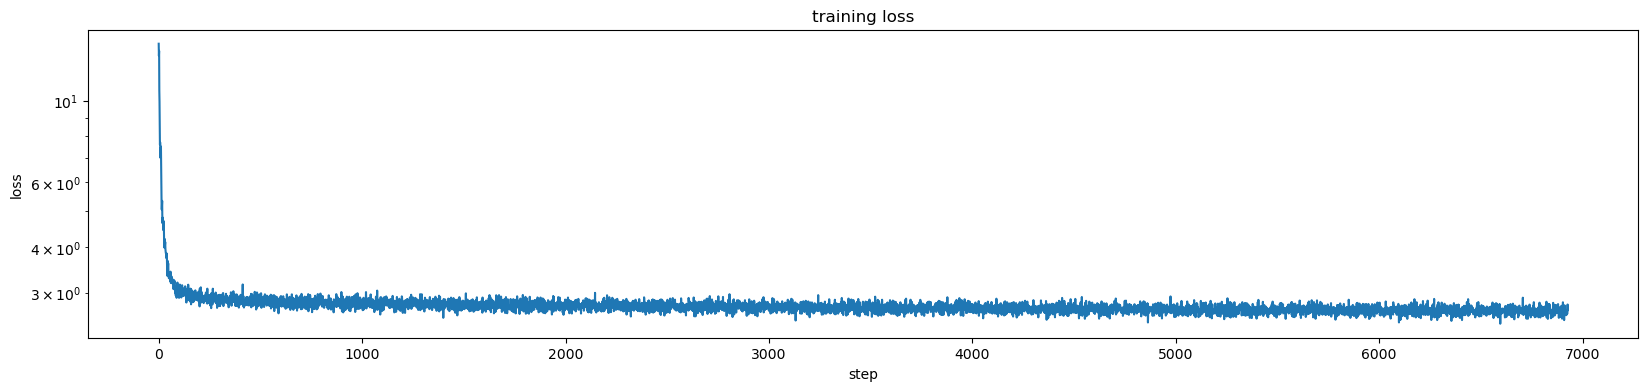

dev loss: 2.6854


In [6]:
layer_sizes = [200]
net = NeuralNetwork(vocab_size, block_size, layer_sizes)

print(f"Number of parameters: {sum(p.numel() for p in net.parameters())}")
print(f"Network architecture:\n{net}")

optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)
batch_size = 512
num_epochs = 4
lossi = []

for epoch in range(num_epochs):
    for step in range(0, Xtr.shape[0], batch_size):
        xb = Xtr[step:step + batch_size]
        yb = Ytr[step:step + batch_size]

        # forward + backward + optimize
        loss = net.loss(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())

    print(f"epoch {epoch + 1:2d} | loss {loss.item():.4f}")

# evaluate on dev set
with torch.no_grad():
    dev_loss = net.loss(Xdev, Ydev)

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.plot(lossi)
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('training loss')
plt.show()

print(f"dev loss: {dev_loss.item():.4f}")

## Generate text from the model
Sample one character at a time from the trained model, feeding each sampled character back into the context to produce new text.

In [7]:
@torch.no_grad()
def generate_text(net, start_text=' ', max_new_chars=100):
    net.eval()
    context = [0] * block_size
    out = start_text

    for ch in start_text:
        ix = stoi[ch]
        context = context[1:] + [ix]

    for _ in range(max_new_chars):
        x = torch.tensor([context], dtype=torch.long)
        logits = net(x)
        probs = torch.softmax(logits, dim=-1)[0]
        ix = torch.multinomial(probs, num_samples=1).item()
        ch = itos[ix]
        out += ch
        context = context[1:] + [ix]

    return out

print(generate_text(net, start_text='hello', max_new_chars=100))

hellonrns..-.a.s...hhe..fLnRA...p...hrse....o...whsuy...sr.s...ho....p.l...wo..aOnA..aHeG...LS.BEOSZS....
